## Challenge

The challenge concludes with a grader cell with which participants can submit their solution to our grading system.
The grading consists of an automated sanity check and a following manual check of the top submissions.
This challenge awards points corresponding to the hypervolume induced by the submitted samples.

#### Hints
We expect the best submissions to this challenge to involve innovation in:
- QAOA ansatz: There could be better ways to sample solutions from the weighted sum of objective functions. You can vary the number of QAOA layers (`p_layers` in above code) to tradeoff an increase in noise with potentially sampling closer to the optimum.
- QAOA parameters: The QAOA parameters on file are determined by a coarse simulation. Fine-tuning the parameters may allow for higher-quality samples and thus to a faster time to result or a better hypervolume. One way of potentially determining better parameters is described in the [Optimization with light-cones](https://github.com/qiskit-community/qaoa_training_pipeline/blob/main/how_tos/light_cone_optimization.ipynb) how-to notebook, but there also other approaches mentioned in this repository.
- Transpilation: The structure of the graphs in this challenge is regular and may therefore yield improvements via structure-specific transpilation methods. One example of such methods is given in the [How to apply optimal QAOA transpilation with a StagedPassManager](https://github.com/qiskit-community/qopt-best-practices/blob/main/how_tos/how_to_apply_optimal_qaoa_transpilation.ipynb) notebook.  This transpilation method is also used for the 42-qubit example above, but the swapping strategy needs to be adapted to the 3-regular structure of the input graph.
- Quantum error mitigation: Running a quantum circuit on a QPU will inevitebly incur errors. The QMOO approach presented in this notebook is natively resilient against noise, but improving the quality of the samples may allow you to find a solution more efficiently or effectively. Local searches similar to configuration recovery methods in sampling-based quantum diaganlization (SQD) or other post-selection approaches may be beneficial. 
- Post-processing: There may be more efficient ways to explore the Pareto front of the graph problems introduced in this challenge.
Make sure you are not assuming any information about the solution to the MOO problem to determine a suitable error mitigation or post-processing technique!

We are curious about novelty in any other aspect and look forward to your submission!

In [1]:
from qmoo_files import load_problem
from qmoo_plot import plot_graphs, plot_pareto_hv

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerOptions, SamplerV2
from qiskit.circuit import ParameterVector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from qiskit.transpiler import CouplingMap
from qiskit.circuit.library.standard_gates.equivalence_library import _sel
from qiskit_aer.primitives import SamplerV2 as SamplerAerV2

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.transpilation import UnrollBoxes
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import generate_preset_qaoa_pass_manager

from qopt_best_practices.sat_mapping import SATMapper
from qopt_best_practices.qubit_selection import BackendEvaluator
from qiskit.transpiler import Layout

from matplotlib import pyplot as plt
from moocore import hypervolume, filter_dominated


import networkx as nx
import numpy as np

In [2]:
# Load your IBM Account

#service = QiskitRuntimeService(name="r2p-2026")
service = QiskitRuntimeService(
    instance="road-to-prac-second-edition_on_prem"
)
# PROMPT Define your prefered backend 

backend = service.backend("ibm_basquecountry")


print(f"Using backend {backend.name}")

Using backend ibm_basquecountry


### Challenge: Max-cut on static 3-regular 80-node graphs [75pts]

loading ./instances/3_regular_static_80q/problem_graph_*.json


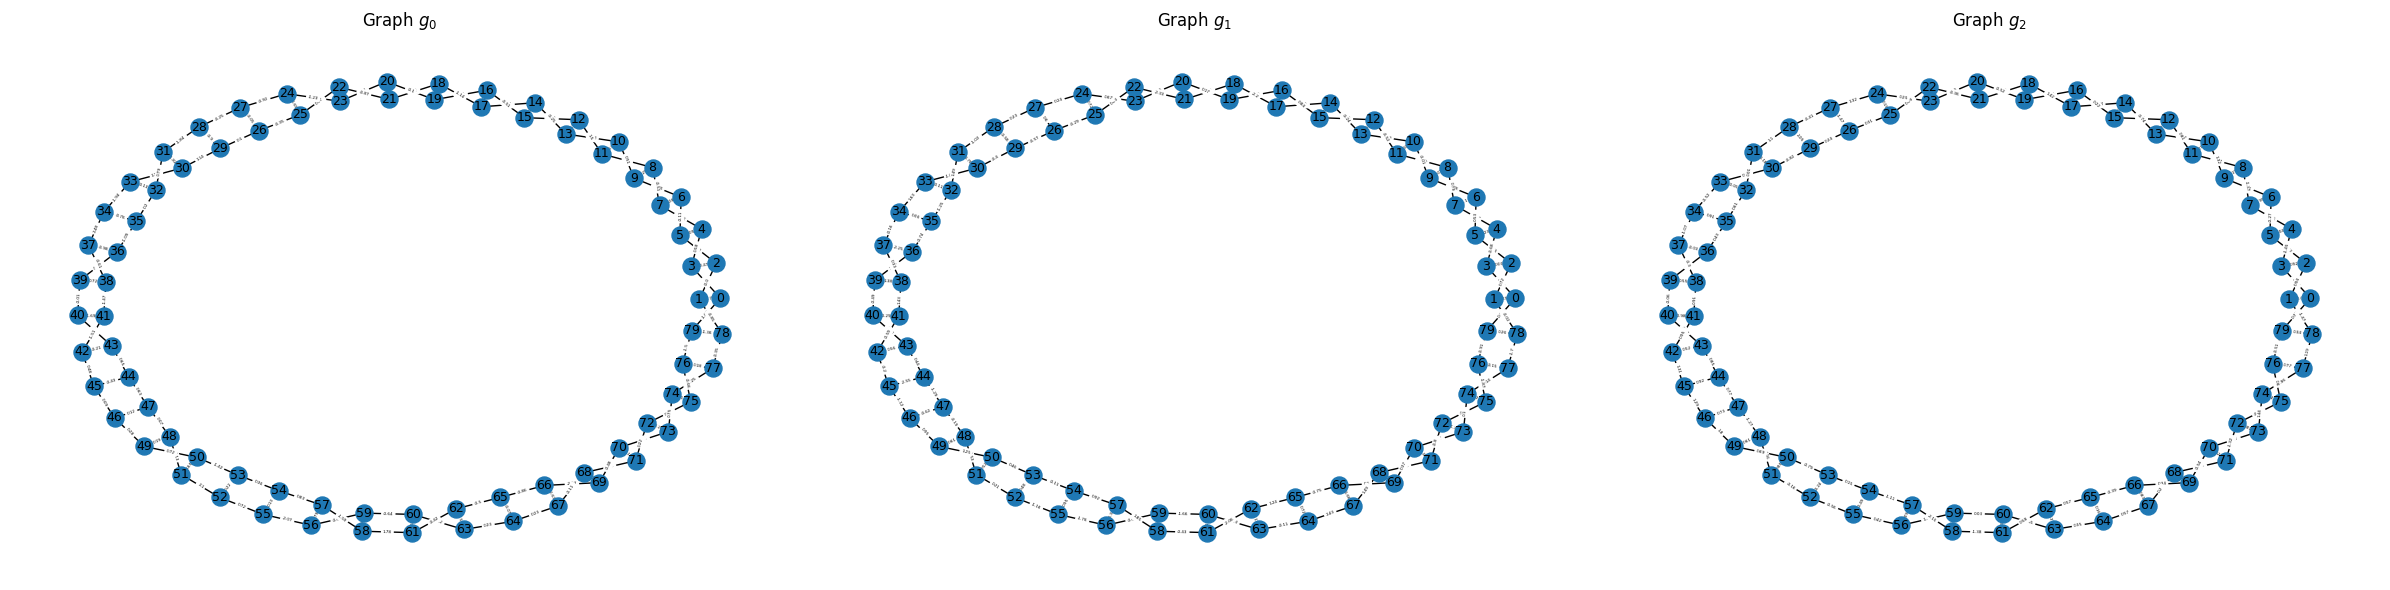

In [3]:
# Note that the QAOA parameters loaded from file here are determined by a coarse simulation and can likely be improved
# you can find 12-node graphs at "./instances/3_regular_static_12q/" and "./instances/circle_12q/" for prototyping purposes
moo_graphs, qaoa_params, upper_bounds, lower_bounds = load_problem("./instances/3_regular_static_80q/")

plot_graphs(moo_graphs)

In [4]:
# PROMPT
# 1a) Prepare the Ansatz circuit
# BEGIN ANSWER
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz

p_layers = 2
maxcuts = [Maxcut(g) for g in moo_graphs]
cost_ops = [to_ising(mc.to_optimization_problem())[0].simplify() for mc in maxcuts]
c_vec = ParameterVector("c", len(cost_ops))
sum_cost_op = sum(c_vec[idx] * hc for idx, hc in enumerate(cost_ops)).simplify()

# Note that we created an ansatz circuit where the individual QAOA cost and QAOA mixer layers are annotated for improved transpilation
qc = annotated_qaoa_ansatz(sum_cost_op, reps=p_layers)
qc.measure_all(inplace=True)
# qc.draw(idle_wires=False,fold=-1)
# END ANSWER

In [5]:
# PROMPT
# 1b) Train the Ansatz parameters or use qaoa_params
# qaoa_params is a dictionary that contains the QAOA \beta-, and 
# \gamma-parameters for p=1 and p=2 QAOA layers, i.e. {"1": {"\beta[0]": ...}}, "2": {"\beta[0]": ..., "\beta[1]": ...}
# BEGIN ANSWER
from qaoa_training_pipeline.evaluation import LightConeEvaluator
from qaoa_training_pipeline.training import ScipyTrainer
from qaoa_training_pipeline.evaluation import MPSEvaluator, StatevectorEvaluator


load_params_file = True

if load_params_file:
    # load low-effort QAOA parameters from file, see `else` branch for how to get advanced QAOA parameters
    params =  [2.054655122149272, 0.2506774780151794, 0.7924114930258584, 1.441851592267535] 
    qaoa_params = {"β[0]": params[0], "β[1]": params[1], "γ[0]": params[2], "γ[1]": params[3]}
    ansatz_qc = qc.assign_parameters(qaoa_params)
else:
    # FIRST, we train QAOA using the QAOA training pipeline
    trainer = ScipyTrainer(MPSEvaluator(bond_dim_circuit=20), minimize_args={"options": {"maxiter": 500}})
    # Use an exact simulator for small-scale quantum computations
    # trainer = ScipyTrainer(StatevectorEvaluator())

    # parameter initialization according to https://arxiv.org/pdf/2101.05742
    dt = 0.75
    grid = np.arange(1, p_layers + 1) - 0.5
    init_params = np.concatenate((1 - grid * dt / p_layers, grid * dt / p_layers))

    # `train` minimizes the cost operator, note the -1 prefactor
    training_result = trainer.train(sum(-1/len(cost_ops) * hc for hc in cost_ops).simplify(), init_params)
    optimized_list = training_result['optimized_params'] # Esta es la LISTA de números

    # Aquí creas el diccionario para el circuito (esto está bien)
    betas = {f"β[{i}]": param for i, param in enumerate(optimized_list[:len(optimized_list)//2])}
    gammas = {f"γ[{i}]": param for i, param in enumerate(optimized_list[len(optimized_list)//2:])}
    params_dict = betas | gammas 

    # SECOND we assign the optimized parameters to the cost operator and re-train with a more accurate evaluator (LightConeEvaluator) to get improved parameters for the uniform preference vector (1/3, 1/3, 1/3)
    c_uniform = [1/3, 1/3, 1/3]
    c_dict = {c_vec[i]: c_uniform[i] for i in range(len(c_vec))}
    cost_op = sum_cost_op.assign_parameters(c_dict)
    trainer1 = ScipyTrainer(LightConeEvaluator())
    params1 = trainer1.train(cost_op, optimized_list)
    optimized_list_uniform = params1["optimized_params"]
    print("Depth-one results:\n", params1["optimized_params"], "\n")

# END ANSWER

In [ ]:
# Usamos parámetros de referencia
# Usamos 1/3 para los c y valores fijos (p.ej. 1.0) para los ángulos de QAOA
reference_dict = {p: (1/3 if 'c' in p.name else 1.0) for p in qc.parameters}

# Creamos el circuito de referencia que tiene que ser numererico
qc_reference = qc.assign_parameters(reference_dict)

def transpile_with_sat_reference(qc_ref, ansatz_original, backend, sum_cost_op):
    aux_c_dict = {p: 1/3 for p in sum_cost_op.parameters}
    cost_op_ref = sum_cost_op.assign_parameters(aux_c_dict)

    swap_strat = SwapStrategy.from_line(range(cost_op_ref.num_qubits))
    
    print("Ejecutando SATMapper con punto de referencia...")
    sat_cost_op, edge_map, min_k = SATMapper().remap_graph_with_sat(cost_op_ref, swap_strat)

    path_finder = BackendEvaluator(backend)
    path, _, _ = path_finder.evaluate(sat_cost_op.num_qubits)

    initial_layout = Layout.from_intlist(path, ansatz_original.qregs[0])
    
    qaoa_pm = generate_preset_qaoa_pass_manager(
        backend, swap_strat, initial_layout=initial_layout, 
        edge_coloring={(idx, idx+1): idx%1 for idx in range(cost_op_ref.num_qubits-1)}
    )
    
    ansatz_original.measure_all()

    # Aplicamos el mapeo calculado al circuito original que tiene los parámetros libres
    return qaoa_pm.run(ansatz_original)

# Ejecutamos
isa_qc_template = transpile_with_sat_reference(qc_reference, qc, backend, sum_cost_op)

Ejecutando SATMapper con punto de referencia...


In [ ]:
# PROMPT
# 2) Transpile the Ansatz circuit [10 pts]
# BEGIN ANSWER

# we first need to transpile the circuit before running it on a real device!
# see https://github.com/qiskit-community/qopt-best-practices/tree/main/how_tos for further transpilation improvements   
# swap strategy and coloring for native heavy-hex graphs

def transpile_for_heavy_hex(ansatz_qc, backend, sum_cost_op):
    # 1. Define a SWAP strategy and edge coloring for the hardware graph
    swap_strat = SwapStrategy.from_line(range(sum_cost_op.num_qubits))
    edge_coloring = {(idx, idx + 1): idx % 1 for idx in range(sum_cost_op.num_qubits - 1)}

    # 2. SAT mapping to the hardware graph with the defined SWAP strategy and edge coloring
    sat_cost_op, edge_map, min_k = SATMapper().remap_graph_with_sat(sum_cost_op, swap_strat)

    # 3. Find a good initial layout with qubit selection techniques
    # The backend evaluator finds the line of qubits with the best fidelity to map the circuit to
    path_finder = BackendEvaluator(backend)
    path, fidelity, num_subsets = path_finder.evaluate(sat_cost_op.num_qubits)

    # 4. Apply a preset QAOA pass manager with the above defined custom passes
    initial_layout = Layout.from_intlist(path, ansatz_qc.qregs[0])
    qaoa_pm = generate_preset_qaoa_pass_manager(backend, swap_strat, initial_layout=initial_layout, edge_coloring=edge_coloring)
    ansatz_qc.measure_all()
    isa_qc = qaoa_pm.run(ansatz_qc)

    print("Two-qubit gate depth", isa_qc.depth(lambda x: len(x.qubits)>1))
    print("Number of two-qubit gates", isa_qc.num_nonlocal_gates())
    
    return isa_qc

c_uniform = [1/3, 1/3, 1/3]
c_dict = {c_vec[i]: c_uniform[i] for i in range(len(c_vec))}
cost_op = sum_cost_op.assign_parameters(c_dict)
isa_qc = transpile_for_heavy_hex(ansatz_qc, backend, cost_op)
# END ANSWER

In [ ]:
# The following grader assumes p=1 QAOA layers, please feel free to use p > 1 for the rest of the challenge!
grader_ch1_ex3(isa_qc)

In [ ]:
# PROMPT
# 3) Generate weight vectors `c_vecs` and sample from the Ansatz circuit
# BEGIN ANSWER
# c_vecs = gen_cvecs(n_samples=n_samples, n_obj=n_obj)

# set error mitigation options for the sampler
options = SamplerOptions()
options.resilience_level = 1   # readout mitigation (Twirled Readout Error Extinction)
options.max_execution_time = 600
sampler = SamplerV2(mode=backend, options=options)
    
job = sampler.run([(isa_qc, c_vecs)], shots=shots)
print("Submitted job to", backend.name, "with id", job.job_id(), "and the following options")
sampler.options

sample_res = job.result()
sample_counts = [sample_res[0].data.meas.get_counts(s) for s in range(n_samples)] 
# END ANSWER


In [ ]:
# PROMPT
# 4) Post-process the samples into the Hypervolume / Pareto front
# BEGIN ANSWER
# Here, we copy the string to our new location, interpret it as ASCII characters where a '0' has the value 48 and a '1' has the value 49, and get to an array of Boolean values by subtracting 48 it from it.
bitstring_length = len(next(iter(sample_counts[0].keys())))
x = np.fromiter((np.frombuffer(k.encode("ascii"), dtype="u1") - 48 for i in range(n_samples) for k in sample_counts[i].keys()), dtype=np.dtype((np.uint8, bitstring_length)))


# get the adjacency matrix of each graph
adj_m = [nx.adjacency_matrix(moo_graphs[i]).toarray() for i in range(n_obj)]
# compute the max-cut value for each input graph, note that `x` is a Boolean array so `1-x` is its complement, thus `x`adj_m`(1-x)` selects exactly the edges (and their weights) across the cut
fis = np.stack([np.sum((x @ adj_m[i]) * (1 - x), axis=1) for i in range(n_obj)], axis=1)
# process each sample only once 
fis = np.unique(fis, axis=0)

# set the reference point from which to compute the Hypervolume
hv_ref_point = np.array(lower_bound)
print("Reference Point", hv_ref_point)

num_batches = 1000 if len(fis) > 10000 else len(fis)//10
batch_size = int(len(fis)/num_batches)
hvs = []
for i in range(batch_size, len(fis), batch_size):
    # use an external library to determine the pareto front and its Hypervolume
    hv = hypervolume(fis[:i], ref=hv_ref_point, maximise=True)
    hvs.append(hv)

# included all samples in the last Hypervolume computation
hvs.append(hypervolume(fis, ref=hv_ref_point, maximise=True))


# the Pareto front is determined during the hypervolume computation, we assign it explictly here
pareto_front = filter_dominated(fis)
print("Hypervolume induced by all samples", hvs[-1])
print("The Pareto front is defined by", len(pareto_front), "points.")
print("A point of the Pareto front is", pareto_front[0])
# END ANSWER


The grading function assumes the following input arguments:
1. The hypervolume determined by your solution `max(hvs)`
2. The samples `x` obtained by your solution
3. The set of QAOA parameters used `params`
4. The job ID(s) used to determine the hypervolume in 1 `[job.job_id()]`

Optionally, you can provide a post-processing function that yields a new array of samples from the original samples.
Note that the grading function can take a couple of minutes to complete.
Also note that the grader will store some of these input arguments in timestamped files that we will check manually for the top submissions of this challenge (please do not remove these files).

In [ ]:
# Grader cell
grader_ch1_ex4(max(hvs), x, isa_qc, params, [job.job_id()])
print("Hypervolume", max(hvs))
print("QPU runtime", max(seconds))